In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv("dead_stock_features.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:")
print(df.head(3))

Shape: (118, 16)

Columns: ['Product Name', 'total_qty_sold', 'total_revenue', 'order_count', 'avg_unit_price', 'first_order_date', 'last_order_date', 'days_since_last_sale', 'active_days', 'weekly_sales_velocity', 'revenue_pct', 'revenue_cumsum', 'ABC', 'cv_value', 'XYZ', 'ABC_XYZ']

Sample:
                                    Product Name  total_qty_sold  \
0      Field & Stream Sportsman 16 Gun Fire Safe           17325   
1               Perfect Fitness Perfect Rip Deck           73698   
2  Diamondback Women's Serene Classic Comfort Bi           13729   

   total_revenue  order_count  avg_unit_price first_order_date  \
0   6.929654e+06        17325      399.980011       2015-01-01   
1   4.421143e+06        24515       59.990002       2015-01-01   
2   4.118426e+06        13729      299.980011       2015-01-01   

  last_order_date  days_since_last_sale  active_days  weekly_sales_velocity  \
0      2017-10-02                   121         1006                120.552   
1      201

In [3]:
# A product is dead stock if ANY of these are true:
# 1. Not sold in last 90 days
# 2. Sells less than 0.5 units per week
# 3. Falls in low value + unpredictable segment (CZ, CY, BZ)

DAYS_THRESHOLD     = 90
VELOCITY_THRESHOLD = 0.5

df['dead_stock_rule'] = (
    (df['days_since_last_sale'] >= DAYS_THRESHOLD) |
    (df['weekly_sales_velocity'] <= VELOCITY_THRESHOLD) |
    (df['ABC_XYZ'].isin(['CZ', 'CY', 'BZ']))
).astype(int)

print("Rule-based dead stock count:", df['dead_stock_rule'].sum())
print(f"That is {df['dead_stock_rule'].mean()*100:.1f}% of all products")

Rule-based dead stock count: 118
That is 100.0% of all products


In [4]:
# ML model that finds products behaving abnormally
# compared to all other products

features_for_ml = [
    'total_qty_sold',
    'weekly_sales_velocity',
    'days_since_last_sale',
    'order_count'
]

X = df[features_for_ml].fillna(0)

iso = IsolationForest(
    n_estimators  = 200,
    contamination = 0.15,   # assume 15% products are dead/anomalous
    random_state  = 42
)

df['iso_flag'] = iso.fit_predict(X)
df['dead_stock_ml'] = (df['iso_flag'] == -1).astype(int)

print("ML-based dead stock count:", df['dead_stock_ml'].sum())
print(f"That is {df['dead_stock_ml'].mean()*100:.1f}% of all products")

ML-based dead stock count: 18
That is 15.3% of all products


In [5]:
# If EITHER rule OR ML flags a product → mark as dead stock
df['dead_stock_final'] = (
    (df['dead_stock_rule'] == 1) |
    (df['dead_stock_ml']   == 1)
).astype(int)

print("Final dead stock count:", df['dead_stock_final'].sum())

# Recommendation for each product
def recommend(row):
    if row['dead_stock_final'] == 1:
        if row['days_since_last_sale'] > 180:
            return 'LIQUIDATE'       # not sold in 6 months → get rid of it
        else:
            return 'DISCOUNT'        # not sold recently → put on sale
    elif row['ABC'] == 'A' and row['XYZ'] == 'X':
        return 'MAINTAIN STOCK'      # top product, consistent → keep stocked
    else:
        return 'MONITOR'             # everything else → watch it

df['recommendation'] = df.apply(recommend, axis=1)

print("\nRecommendation breakdown:")
print(df['recommendation'].value_counts())

Final dead stock count: 118

Recommendation breakdown:
recommendation
DISCOUNT     73
LIQUIDATE    45
Name: count, dtype: int64


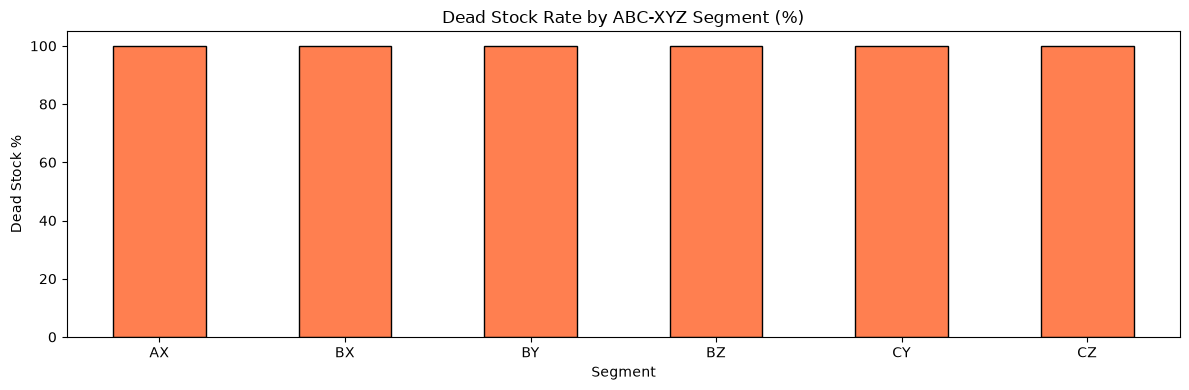

Plot saved ✅


In [6]:
# How many dead stock products in each ABC-XYZ segment?
dead_by_seg = df.groupby('ABC_XYZ')['dead_stock_final'].mean() * 100

plt.figure(figsize=(12, 4))
dead_by_seg.sort_values(ascending=False).plot(
    kind='bar', color='coral', edgecolor='black'
)
plt.title('Dead Stock Rate by ABC-XYZ Segment (%)')
plt.xlabel('Segment')
plt.ylabel('Dead Stock %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("dead_stock_by_segment.png")
plt.show()
print("Plot saved ✅")

In [7]:
output_cols = [
    'Product Name',
    'total_qty_sold',
    'total_revenue',
    'days_since_last_sale',
    'weekly_sales_velocity',
    'ABC', 'XYZ', 'ABC_XYZ',
    'dead_stock_final',
    'recommendation'
]

dead_stock_output = df[output_cols].copy()
dead_stock_output.to_csv("dead_stock_output.csv", index=False)
print("Saved ✅ → dead_stock_output.csv")

# Show worst products
print("\nTop 10 products to LIQUIDATE:")
liquidate = dead_stock_output[
    dead_stock_output['recommendation'] == 'LIQUIDATE'
].sort_values('days_since_last_sale', ascending=False)

print(liquidate[['Product Name', 'days_since_last_sale',
                 'weekly_sales_velocity', 'total_revenue']].head(10).to_string())

Saved ✅ → dead_stock_output.csv

Top 10 products to LIQUIDATE:
                                     Product Name  days_since_last_sale  weekly_sales_velocity  total_revenue
46  Bridgestone e6 Straight Distance NFL Tennesse                   302                  6.830   25751.949756
54      adidas Men's Germany Black Crest Away Tee                   294                  7.253   21475.000000
48     Team Golf Tennessee Volunteers Putter Grip                   292                  7.671   22865.849747
32                     TYR Boys' Team Digi Jammer                   288                  7.351   35191.200633
29                    Titleist Pro V1x Golf Balls                   288                  7.226   41415.370528
38    Under Armour Hustle Storm Medium Duffle Bag                   288                  7.075   29601.540642
36                       ENO Atlas Hammock Straps                   288                  8.356   29930.019742
56             Under Armour Men's Tech II T-Shirt        

In [8]:
print("=" * 42)
print("   DEAD STOCK DETECTION COMPLETE")
print("=" * 42)
print(f"  Total products     : {len(df)}")
print(f"  Dead stock flagged : {df['dead_stock_final'].sum()}")
print(f"  To LIQUIDATE       : {(df['recommendation']=='LIQUIDATE').sum()}")
print(f"  To DISCOUNT        : {(df['recommendation']=='DISCOUNT').sum()}")
print(f"  To MAINTAIN        : {(df['recommendation']=='MAINTAIN STOCK').sum()}")
print(f"  To MONITOR         : {(df['recommendation']=='MONITOR').sum()}")
print(f"  Output saved       : dead_stock_output.csv")
print("=" * 42)

   DEAD STOCK DETECTION COMPLETE
  Total products     : 118
  Dead stock flagged : 118
  To LIQUIDATE       : 45
  To DISCOUNT        : 73
  To MAINTAIN        : 0
  To MONITOR         : 0
  Output saved       : dead_stock_output.csv
